# 70 — Matriz de experimentos TF-IDF + K-Means e categorização revisada

Este notebook é independente dos notebooks 50 e 60. Ele implementa os cinco passos:
**inspecionar vetores → revisar clusters → comparar representações → comparar k → categorizar e validar**.
A execução automática compara os modelos primeiro e prepara a inspeção dos candidatos ao terminar.

**Como usar:** ajuste a célula de parâmetros e execute **Run All**. Por padrão, são usadas todas as
descrições disponíveis, menos 300 reservadas para validação. A grade tem 6 representações × 8 valores
de k × 3 sementes = **144 ajustes** (cada ajuste usa `n_init=10`).
Ao voltar, veja o ranking, os mapas de calor e os CSVs de revisão. O notebook termina normalmente
com a classificação final pendente de sua escolha e de seus rótulos; ele não inventa categorias.

Cada `RUN_ID` tem relatórios próprios e modelos em `models/`. Copie o identificador exibido
para retomar a mesma execução após reiniciar o kernel. Ajustes concluídos são recuperados;
falhas são registradas individualmente e tentadas novamente na retomada.
Não execute dois kernels simultaneamente com o mesmo identificador.

In [1]:
import json
import logging
from dataclasses import asdict
from datetime import datetime, timezone
from hashlib import sha256
from itertools import product
from uuid import uuid4

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from nofis_classifier.datasets import (
    DEFAULT_PERIOD_LABEL, FILTERED_MARKET_DATASET_NAME,
    load_processed_items, prepare_modeling_items, processed_dataset_path,
)
from nofis_classifier.paths import find_project_root
from nofis_classifier.schema import DESCRIPTION_NORMALIZED, FREQUENCY
from nofis_classifier.tfidf import TfidfExperimentConfig
from nofis_classifier.clustering import (
    split_descriptions, run_clustering_grid, rank_experiments, load_local_model,
    inspect_documents, build_cluster_review, save_review_once, predict_categories,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logger = logging.getLogger("notebook70")
pd.set_option("display.max_colwidth", 160)

## 1. Parâmetros e matriz experimental

`word (1,1)` representa palavras; `word (1,2)` acrescenta pares de palavras;
`char_wb (3,5)` usa fragmentos de 3 a 5 caracteres dentro das palavras, com bordas.
`min_df` exige que o termo apareça em pelo menos esse número de descrições de treino.
`max_features` limita o vocabulário. Adicione valores nas listas abaixo para ampliar a grade.

`k` é a quantidade de grupos solicitados. `n_init` escolhe a melhor inicialização por inércia
dentro de cada ajuste. As três sementes repetem o experimento para mostrar a variação das métricas.
Essa variação não mede diretamente a concordância entre os agrupamentos.

O peso de cada descrição única no treino é igual. `frequencia` serve para medir a importância
prática dos grupos, não para ponderar o ajuste. A representação não usa NCM ou rótulos humanos.

In [2]:
RUN_ID = None  # Para retomar, cole aqui o identificador exibido na próxima seção.
DATASET_NAME = FILTERED_MARKET_DATASET_NAME
PERIOD_LABEL = DEFAULT_PERIOD_LABEL
MAX_DESCRIPTIONS = None  # None = toda a base; reduza somente para um teste rápido.
VALIDATION_COUNT = 300
SPLIT_SEED = 42

REPRESENTATIONS = [
    ("word", (1, 1), [10_000]),
    ("word", (1, 2), [10_000]),
    ("char_wb", (3, 5), [30_000]),
]
MIN_DF_VALUES = [2, 5]
K_VALUES = [10, 15, 20, 25, 30, 40, 60, 80]
SEEDS = [42, 123, 2026]
N_INIT = 10
MAX_ITER = 300
METRIC_SAMPLE_SIZE = 1_000  # Mesmas posições de treino para toda a grade.
DENSE_LIMIT_MB = 512  # Limite para a matriz densa da amostra de CH/DB, não para o processo todo.
TOP_COMBINATIONS = 3

In [3]:
configs = [
    TfidfExperimentConfig(
        name=f"{analyzer}_{ngrams[0]}_{ngrams[1]}_df{min_df}_max{limit}",
        analyzer=analyzer, ngram_range=ngrams, min_df=min_df, max_features=limit,
    )
    for analyzer, ngrams, limits in REPRESENTATIONS
    for min_df, limit in product(MIN_DF_VALUES, limits)
]
experiment_matrix = pd.DataFrame([
    {**asdict(config), "k": k, "seed": seed, "n_init": N_INIT}
    for config, k, seed in product(configs, K_VALUES, SEEDS)
])
display(experiment_matrix)
logger.info("Grade planejada: %d ajustes", len(experiment_matrix))

,name,analyzer,ngram_range,min_df,max_features,max_df,sublinear_tf,norm,k,seed,n_init
0,word_1_1_df2_max10000,word,"(1, 1)",2,10000,0.95,True,l2,10,42,10
1,word_1_1_df2_max10000,word,"(1, 1)",2,10000,0.95,True,l2,10,123,10
2,word_1_1_df2_max10000,word,"(1, 1)",2,10000,0.95,True,l2,10,2026,10
3,word_1_1_df2_max10000,word,"(1, 1)",2,10000,0.95,True,l2,15,42,10
4,word_1_1_df2_max10000,word,"(1, 1)",2,10000,0.95,True,l2,15,123,10
...,...,...,...,...,...,...,...,...,...,...,...
139,char_wb_3_5_df5_max30000,char_wb,"(3, 5)",5,30000,0.95,True,l2,60,123,10
140,char_wb_3_5_df5_max30000,char_wb,"(3, 5)",5,30000,0.95,True,l2,60,2026,10
141,char_wb_3_5_df5_max30000,char_wb,"(3, 5)",5,30000,0.95,True,l2,80,42,10
142,char_wb_3_5_df5_max30000,char_wb,"(3, 5)",5,30000,0.95,True,l2,80,123,10


2026-09-27 13:31:11,454 INFO Grade planejada: 144 ajustes


## 2. Dados, reserva de validação e identificação da execução

A divisão ocorre por descrição normalizada única **antes de ajustar o vocabulário**.
As descrições reservadas não participam do TF-IDF, do K-Means nem do ranking.
Essa reserva aleatória avalia descrições não vistas da mesma base; não demonstra generalização
para meses futuros. A quantidade de treino será o total disponível menos a reserva.

O manifesto detecta mudança de dados ou parâmetros na retomada. Para outro experimento,
use outro `RUN_ID`. Os dados de origem e modelos de execuções anteriores são preservados.

In [4]:
PROJECT_ROOT = find_project_root()
DATASET_PATH = processed_dataset_path(DATASET_NAME, PERIOD_LABEL, root=PROJECT_ROOT)
items = prepare_modeling_items(load_processed_items(DATASET_PATH))
if MAX_DESCRIPTIONS is not None:
    items = items.sample(n=min(MAX_DESCRIPTIONS, len(items)), random_state=SPLIT_SEED).reset_index(drop=True)
train, validation = split_descriptions(items, VALIDATION_COUNT, SPLIT_SEED)
assert set(train[DESCRIPTION_NORMALIZED]).isdisjoint(validation[DESCRIPTION_NORMALIZED])
assert all(2 <= k < len(train) for k in K_VALUES), "Reduza K_VALUES para esta base."

RUN_ID = RUN_ID or datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid4().hex[:8]
assert all(character.isalnum() or character in "_-" for character in RUN_ID), "RUN_ID inválido"
REPORT_DIR = PROJECT_ROOT / "reports" / "grid_tfidf_kmeans" / f"{PERIOD_LABEL}_{RUN_ID}"
MODEL_DIR = PROJECT_ROOT / "models" / "grid_tfidf_kmeans" / f"{PERIOD_LABEL}_{RUN_ID}"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

run_metadata = {
    "run_id": RUN_ID, "dataset": DATASET_NAME, "period": PERIOD_LABEL,
    "dataset_sha256": sha256(pd.util.hash_pandas_object(items, index=True).values.tobytes()).hexdigest(),
    "validation_count": VALIDATION_COUNT, "split_seed": SPLIT_SEED,
    "max_descriptions": MAX_DESCRIPTIONS,
}
metadata_path = REPORT_DIR / "run.json"
if metadata_path.exists():
    if json.loads(metadata_path.read_text(encoding="utf-8")) != run_metadata:
        raise ValueError("A base ou a divisão mudou; use outro RUN_ID.")
else:
    metadata_path.write_text(json.dumps(run_metadata, indent=2), encoding="utf-8")
save_review_once(train, REPORT_DIR / "training_descriptions.csv")
save_review_once(validation, REPORT_DIR / "heldout_descriptions.csv")
experiment_matrix.to_csv(REPORT_DIR / "planned_grid.csv", index=False)
logger.info("RUN_ID para retomar: %s", RUN_ID)
logger.info("Relatórios: %s", REPORT_DIR)
display(pd.DataFrame({"particao": ["treino", "validacao"],
                      "descricoes": [len(train), len(validation)],
                      "frequencia_total": [train[FREQUENCY].sum(), validation[FREQUENCY].sum()]}))

2026-09-27 13:31:13,454 INFO RUN_ID para retomar: 20260927T163113Z_3df937b0
2026-09-27 13:31:13,454 INFO Relatórios: C:\Users\samue\Scripts\Nofis-Classifier\reports\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0


,particao,descricoes,frequencia_total
0,treino,27500,133117
1,validacao,300,1507


## 3. Executar a grade e salvar cada resultado

Esta é a célula demorada. O TF-IDF é ajustado uma vez por configuração e reutilizado nos valores
de k e sementes. A execução é sequencial para não multiplicar o consumo de memória.
Os modelos são salvos separadamente, e somente uma representação fica carregada por vez.

O treinamento usa **todas as descrições de treino**. Silhouette cosseno, Calinski-Harabasz (CH)
e Davies-Bouldin (DB) usam a mesma amostra fixa. Apenas essa amostra é convertida em matriz densa
para CH/DB; se exceder o limite configurado, essas duas métricas ficam ausentes com justificativa.

Vetores zerados são contados e mantidos, para não mudar silenciosamente a população entre
representações. Uma proporção alta é sinal de vocabulário inadequado e deve pesar na escolha.
Uma amostra pode não conter todos os clusters: confira `sample_clusters` antes de concluir.

In [5]:
metrics = run_clustering_grid(
    train, configs, K_VALUES, SEEDS, REPORT_DIR, MODEL_DIR,
    sample_size=METRIC_SAMPLE_SIZE, sample_seed=SPLIT_SEED,
    n_init=N_INIT, max_iter=MAX_ITER, dense_limit_mb=DENSE_LIMIT_MB,
)
display(metrics)
display(metrics.loc[metrics["status"].ne("ok")])

2026-09-27 13:31:14,302 INFO [1/144] Ajustando: word_1_1_df2_max10000_k10_seed42
2026-09-27 13:31:21,664 INFO [2/144] Ajustando: word_1_1_df2_max10000_k10_seed123
2026-09-27 13:31:22,941 INFO [3/144] Ajustando: word_1_1_df2_max10000_k10_seed2026
2026-09-27 13:31:24,174 INFO [4/144] Ajustando: word_1_1_df2_max10000_k15_seed42
2026-09-27 13:31:26,155 INFO [5/144] Ajustando: word_1_1_df2_max10000_k15_seed123
2026-09-27 13:31:27,939 INFO [6/144] Ajustando: word_1_1_df2_max10000_k15_seed2026
2026-09-27 13:31:29,703 INFO [7/144] Ajustando: word_1_1_df2_max10000_k20_seed42
2026-09-27 13:31:32,302 INFO [8/144] Ajustando: word_1_1_df2_max10000_k20_seed123
2026-09-27 13:31:34,675 INFO [9/144] Ajustando: word_1_1_df2_max10000_k20_seed2026
2026-09-27 13:31:39,376 INFO [10/144] Ajustando: word_1_1_df2_max10000_k25_seed42
2026-09-27 13:31:44,398 INFO [11/144] Ajustando: word_1_1_df2_max10000_k25_seed123
2026-09-27 13:31:51,674 INFO [12/144] Ajustando: word_1_1_df2_max10000_k25_seed2026
2026-09-27 13

,experiment_id,config_name,k,seed,n_init,document_count,sample_size,model_path,vectorizer_path,status,...,max_cluster_size,largest_cluster_fraction,singleton_clusters,silhouette_cosine,calinski_harabasz,davies_bouldin,metric_note,dense_sample_mb,warnings,elapsed_seconds
0,word_1_1_df2_max10000_k10_seed42,word_1_1_df2_max10000,10,42,10,27500,1000,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\word_1_1_df2_max10000_k10_seed42.pkl,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\word_1_1_df2_max10000_tfidf.pkl,ok,...,17353,0.631018,0,0.028517,5.481832,5.306238,,50.651550,,7.354829
1,word_1_1_df2_max10000_k10_seed123,word_1_1_df2_max10000,10,123,10,27500,1000,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\word_1_1_df2_max10000_k10_seed123.pkl,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\word_1_1_df2_max10000_tfidf.pkl,ok,...,17471,0.635309,0,0.030995,5.764595,5.195392,,50.651550,,1.267242
2,word_1_1_df2_max10000_k10_seed2026,word_1_1_df2_max10000,10,2026,10,27500,1000,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\word_1_1_df2_max10000_k10_seed2026.pkl,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\word_1_1_df2_max10000_tfidf.pkl,ok,...,17722,0.644436,0,0.026158,5.092650,5.290669,,50.651550,,1.219598
3,word_1_1_df2_max10000_k15_seed42,word_1_1_df2_max10000,15,42,10,27500,1000,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\word_1_1_df2_max10000_k15_seed42.pkl,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\word_1_1_df2_max10000_tfidf.pkl,ok,...,15575,0.566364,0,0.033084,4.795498,4.866403,,50.651550,,1.972385
4,word_1_1_df2_max10000_k15_seed123,word_1_1_df2_max10000,15,123,10,27500,1000,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\word_1_1_df2_max10000_k15_seed123.pkl,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\word_1_1_df2_max10000_tfidf.pkl,ok,...,15168,0.551564,0,0.040681,4.986374,4.937759,,50.651550,,1.777987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,char_wb_3_5_df5_max30000_k60_seed123,char_wb_3_5_df5_max30000,60,123,10,27500,1000,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\char_wb_3_5_df5_max30000_k60_seed123.pkl,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\char_wb_3_5_df5_max30000_tfidf.pkl,ok,...,9203,0.334655,0,0.088345,3.831657,3.246792,,178.375244,,61.753104
140,char_wb_3_5_df5_max30000_k60_seed2026,char_wb_3_5_df5_max30000,60,2026,10,27500,1000,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\char_wb_3_5_df5_max30000_k60_seed2026.pkl,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\char_wb_3_5_df5_max30000_tfidf.pkl,ok,...,9076,0.330036,0,0.083099,3.743081,3.214300,,178.375244,,61.788008
141,char_wb_3_5_df5_max30000_k80_seed42,char_wb_3_5_df5_max30000,80,42,10,27500,1000,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\char_wb_3_5_df5_max30000_k80_seed42.pkl,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\char_wb_3_5_df5_max30000_tfidf.pkl,ok,...,8061,0.293127,0,0.095831,3.487443,2.947144,,178.375244,,87.154219
142,char_wb_3_5_df5_max30000_k80_seed123,char_wb_3_5_df5_max30000,80,123,10,27500,1000,C:\Users\samue\Scripts\Nofis-Classifier\models\grid_tfidf_kmeans

,experiment_id,config_name,k,seed,n_init,document_count,sample_size,model_path,vectorizer_path,status,...,max_cluster_size,largest_cluster_fraction,singleton_clusters,silhouette_cosine,calinski_harabasz,davies_bouldin,metric_note,dense_sample_mb,warnings,elapsed_seconds


## 4. Comparar métricas e selecionar candidatos

| Evidência | Interpretação |
|---|---|
| Silhouette cosseno | Maior sugere melhor separação na representação avaliada; não é acurácia. |
| Calinski-Harabasz | Maior sugere maior separação relativa à dispersão. |
| Davies-Bouldin | Menor sugere menor sobreposição relativa. |
| Inércia | Use o cotovelo **dentro da mesma representação e base**; não compare vocabulários por ela. |
| Maior cluster / vetores zerados | Diagnósticos para detectar concentração e perda de informação. |
| Desvio da Silhouette entre sementes | Mostra variação da métrica com a inicialização. |

O ranking usa a **mediana da Silhouette entre sementes**, com menor desvio como desempate.
Combinações com falha, Silhouette indefinida ou menos clusters efetivos que k são excluídas.
CH/DB ficam visíveis separadamente; não há soma arbitrária de métricas em escalas diferentes.
As métricas em espaços de representação diferentes são evidências exploratórias,
não uma prova de que a primeira configuração categoriza melhor.

Selecionamos as três primeiras combinações e os líderes de CH e DB, sem duplicatas.
Para cada combinação, revisamos a execução cuja Silhouette é mais próxima da mediana.
**A decisão final continua dependendo da revisão humana.**

In [6]:
# Recarrega os resultados mesmo após reiniciar o kernel e retomar a execução.
metrics = pd.read_csv(REPORT_DIR / "metrics.csv")
ranking = rank_experiments(metrics, expected_seeds=SEEDS)
if ranking.empty:
    raise RuntimeError("Nenhuma combinação elegível. Consulte status, error e metric_note em metrics.csv.")
ranking.to_csv(REPORT_DIR / "ranking.csv", index=False)
display(ranking)

candidate_ids = ranking.head(TOP_COMBINATIONS)["representative_id"].tolist()
for column, ascending in [("ch_median", False), ("db_median", True)]:
    leaders = ranking.dropna(subset=[column]).sort_values(column, ascending=ascending)
    if not leaders.empty:
        candidate_ids.append(leaders.iloc[0]["representative_id"])
candidate_ids = list(dict.fromkeys(candidate_ids))
candidates = metrics.set_index("experiment_id").loc[candidate_ids].reset_index()
candidates.to_csv(REPORT_DIR / "candidates.csv", index=False)
display(candidates[["experiment_id", "silhouette_cosine", "calinski_harabasz",
                    "davies_bouldin", "largest_cluster_fraction", "zero_vector_fraction"]])

,config_name,k,seed_count,silhouette_median,silhouette_std,ch_median,db_median,inertia_median,largest_cluster_fraction,zero_vector_fraction,reached_max_iter,representative_id
0,char_wb_3_5_df2_max30000,80,3,0.089917,0.001438,3.414301,3.071269,22333.429507,0.275236,0.000000,False,char_wb_3_5_df2_max30000_k80_seed2026
1,char_wb_3_5_df5_max30000,80,3,0.089267,0.003296,3.487443,2.982050,22206.763583,0.278873,0.000000,False,char_wb_3_5_df5_max30000_k80_seed123
2,char_wb_3_5_df5_max30000,60,3,0.083099,0.003295,3.793177,3.246792,22943.642441,0.330036,0.000000,False,char_wb_3_5_df5_max30000_k60_seed2026
3,char_wb_3_5_df2_max30000,60,3,0.077843,0.001672,3.643789,3.214875,23073.705020,0.336000,0.000000,False,char_wb_3_5_df2_max30000_k60_seed42
4,char_wb_3_5_df2_max30000,40,3,0.068663,0.001469,4.143707,3.765251,23932.590235,0.365855,0.000000,False,char_wb_3_5_df2_max30000_k40_seed2026
5,char_wb_3_5_df5_max30000,40,3,0.067952,0.000733,4.242865,3.625828,23858.540738,0.399200,0.000000,False,char_wb_3_5_df5_max30000_k40_seed2026
6,word_1_1_df5_max10000,80,3,0.067414,0.016188,3.182482,3.051278,22720.818621,0.274291,0.007273,False,word_1_1_df5_max10000_k80_seed42
7,word_1_1_df2_max10000,80,3,0.061678,0.002981,2.911869,3.209947,23267.075160,0.269782,0.002691,False,word_1_1_df2_max10000_k80_seed123
8,word_1_1_df5_max10000,60,3,0.061581,0.007529,3.433866,3.354338,23351.701475,0.316982,0.007273,False,word_1_1_df5_max10000_k60_seed123
9,char_wb_3_5_df2_max30000,30,3,0.059904,0.000934,4.438767,4.050984,24510.483669,0.430691,0.000000,False,char_wb_3_5_df2_max30000_k30_seed2026


,experiment_id,silhouette_cosine,calinski_harabasz,davies_bouldin,largest_cluster_fraction,zero_vector_fraction
0,char_wb_3_5_df2_max30000_k80_seed2026,0.089917,3.414301,3.121275,0.240764,0.000000
1,char_wb_3_5_df5_max30000_k80_seed123,0.089267,3.466461,3.049265,0.266291,0.000000
2,char_wb_3_5_df5_max30000_k60_seed2026,0.083099,3.743081,3.214300,0.330036,0.000000
3,word_1_1_df5_max10000_k10_seed123,0.032695,6.269931,4.766415,0.642145,0.007273


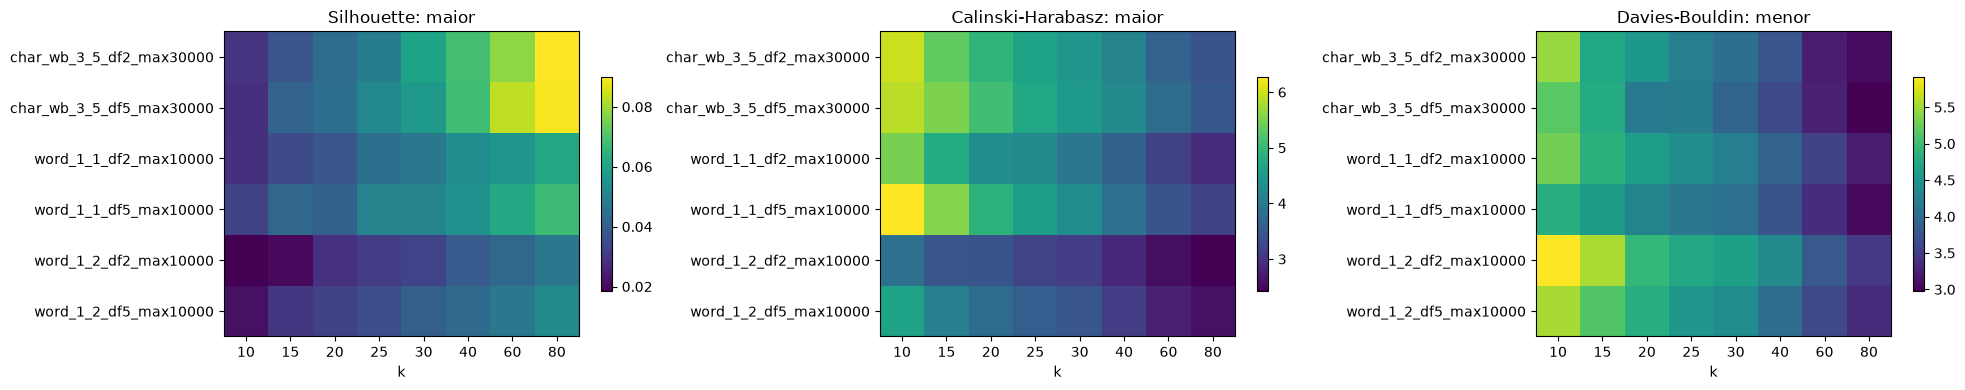

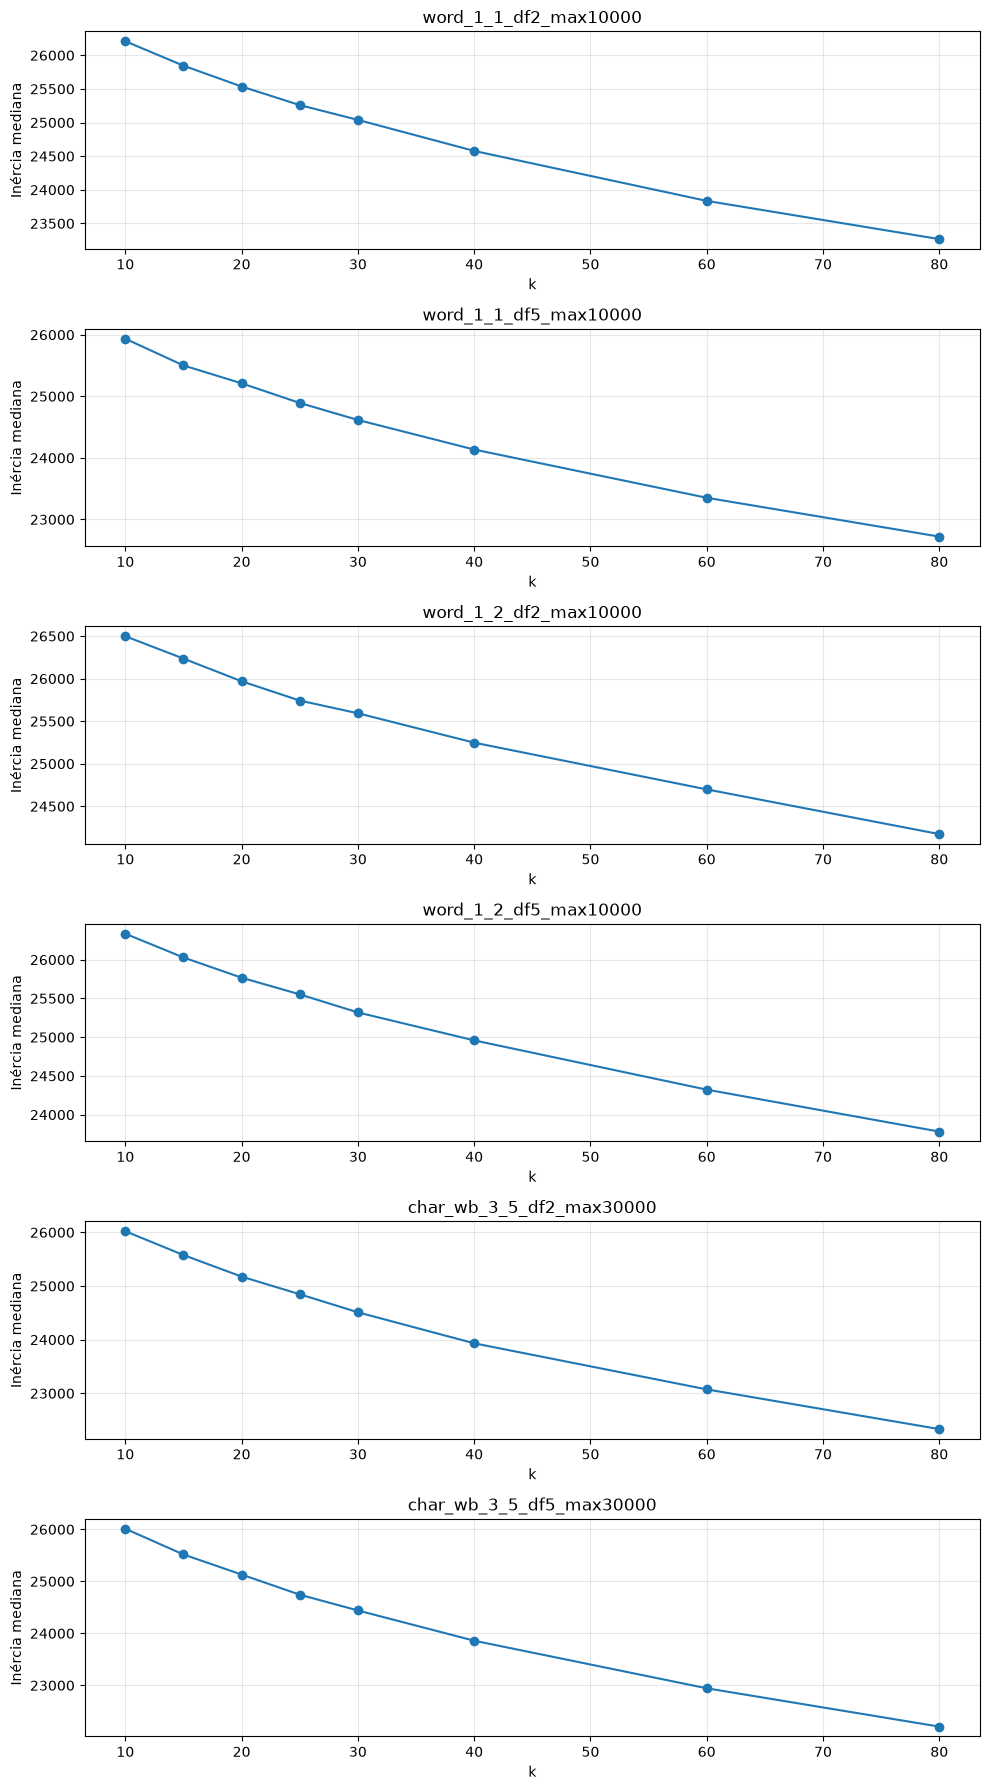

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, max(4, len(configs) * 0.6)))
for ax, metric, title in zip(
    axes, ["silhouette_median", "ch_median", "db_median"],
    ["Silhouette: maior", "Calinski-Harabasz: maior", "Davies-Bouldin: menor"],
):
    table = ranking.pivot(index="config_name", columns="k", values=metric)
    plot = ax.imshow(np.ma.masked_invalid(table.to_numpy(dtype=float)), aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(table.columns)), table.columns)
    ax.set_yticks(range(len(table.index)), table.index)
    ax.set_xlabel("k")
    ax.set_title(title)
    fig.colorbar(plot, ax=ax, shrink=0.7)
fig.tight_layout()
fig.savefig(REPORT_DIR / "metric_heatmaps.png", dpi=140, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(len(configs), 1, figsize=(10, 3 * len(configs)), squeeze=False)
for ax, config in zip(axes.ravel(), configs):
    curve = ranking[ranking.config_name.eq(config.name)].sort_values("k")
    ax.plot(curve["k"], curve["inertia_median"], marker="o")
    ax.set(title=config.name, xlabel="k", ylabel="Inércia mediana")
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(REPORT_DIR / "inertia_by_representation.png", dpi=140, bbox_inches="tight")
plt.show()

## 5. Entender dez vetores e revisar os clusters dos candidatos

Os mesmos dez produtos são inspecionados em cada representação candidata. Leia os termos com
maior peso e identifique se representam produto, marca ou embalagem. As funções auxiliares em
`src/nofis_classifier/clustering.py` cuidam da persistência e da avaliação; as escolhas da pesquisa
ficam nas células deste notebook.

Cada candidato recebe `assignments.csv`, `documents_tfidf.csv` e **`cluster_review.csv`**.
Este último é editável: preencha `avaliacao_qualitativa` com `coerente`,
`parcialmente coerente` ou `heterogeneo`; preencha `rotulo_humano` e `observacoes`.
Comece pelos cinco maiores grupos, mas revise todos os grupos que pretende categorizar.
É permitido dar a mesma categoria a vários clusters. O número do cluster só vale naquele modelo.

Exemplos distantes são os mais afastados do centroide, não necessariamente os mais próximos
da fronteira com outro cluster. Compare-os com os exemplos centrais e aleatórios.
Os CSVs editáveis existentes **não são sobrescritos** quando a célula roda novamente.

In [8]:
for row in candidates.itertuples(index=False):
    candidate_dir = REPORT_DIR / "review" / row.experiment_id
    vectorizer = load_local_model(row.vectorizer_path)
    model = load_local_model(row.model_path)
    documents = inspect_documents(train, vectorizer, count=10, seed=SPLIT_SEED)
    assignments, review = build_cluster_review(train, vectorizer, model, row.experiment_id)
    save_review_once(documents, candidate_dir / "documents_tfidf.csv")
    save_review_once(assignments, candidate_dir / "assignments.csv")
    save_review_once(review, candidate_dir / "cluster_review.csv")
    logger.info("Revisão pronta: %s", candidate_dir)
    display(documents[[DESCRIPTION_NORMALIZED, "termos_tfidf", "sem_vocabulario"]])
    display(pd.read_csv(candidate_dir / "cluster_review.csv").head(5))

2026-09-27 14:13:55,866 INFO Revisão pronta: C:\Users\samue\Scripts\Nofis-Classifier\reports\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\review\char_wb_3_5_df2_max30000_k80_seed2026


,descricao_normalizada,termos_tfidf,sem_vocabulario
24195,rosquinha nossa terra 500g,nossa: 0.212 | noss: 0.201 | nos: 0.199 | noss: 0.199 | ossa : 0.168 | squin: 0.168 | osqui: 0.167 | squi: 0.167 | ossa: 0.167 | rosqu: 0.159,False
13756,lampada bubo led 07w 6500k bivolt,bub: 0.212 | bubo : 0.212 | bubo: 0.212 | bub: 0.212 | bubo: 0.212 | 7w : 0.181 | 07: 0.165 | ubo : 0.152 | ivolt: 0.147 | bivo: 0.146,False
4413,bivack 400 ec 1 l,ec : 0.326 | ec : 0.278 | ack : 0.270 | 400 : 0.258 | 400 : 0.255 | ck : 0.252 | ec: 0.249 | ack: 0.236 | biv: 0.236 | iva: 0.234,False
8897,detergente enzimatico composicao a base de amilase 5lt,ase : 0.161 | ase: 0.149 | zimat: 0.145 | imati: 0.145 | nzima: 0.143 | enzim: 0.143 | nzim: 0.143 | zima: 0.143 | enzi: 0.140 | zim: 0.140,False
18127,molho tom marata bolonhesa pouch,lonh: 0.178 | nhes: 0.178 | onhe: 0.178 | olonh: 0.178 | onhes: 0.178 | hesa: 0.178 | lonhe: 0.178 | nhesa: 0.178 | hesa : 0.178 | bolon: 0.172,False
21150,pincel trincha roma 3 4,inc: 0.227 | roma: 0.194 | rom: 0.194 | roma : 0.183 | oma : 0.176 | roma: 0.166 | incel: 0.166 | ncel : 0.166 | ncel: 0.166 | pince: 0.164,False
6726,coala multiuso tradicional zulu perfumes 500ml,zulu : 0.153 | zulu: 0.153 | ulu : 0.153 | ulu: 0.153 | zulu: 0.153 | fumes: 0.151 | zul: 0.151 | lu : 0.136 | zu: 0.135 | rfume: 0.131,False
18080,molho shoyu,shoyu: 0.249 | oyu : 0.249 | oyu: 0.249 | hoyu : 0.249 | hoyu: 0.249 | yu : 0.248 | shoy: 0.241 | shoy: 0.241 | hoy: 0.241 | sho: 0.237,False
3537,bb ref dafruta pronto 1li maracuja tp,1li : 0.179 | 1li : 0.179 | 1li: 0.165 | 1li: 0.165 | dafr: 0.148 | dafr: 0.148 | dafru: 0.148 | daf: 0.148 | daf: 0.148 | afrut: 0.143,False
8439,desinfetante composicao equilibrada de phmb e tensoativo cationico biodegradavel frasco de 1 litro,rada: 0.116 | tioni: 0.104 | phmb: 0.104 | cati: 0.104 | hmb : 0.104 | phm: 0.104 | hmb: 0.104 | ilibr: 0.102 | ilib: 0.102 | libra: 0.102,False


,experiment_id,cluster,termos_relevantes,exemplos_centrais,exemplos_distantes,exemplos_aleatorios,descricoes_unicas,frequencia_total,sem_vocabulario,avaliacao_qualitativa,rotulo_humano,observacoes
0,char_wb_3_5_df2_max30000_k80_seed2026,0,0g | de | de | pa | ma | co | ra | ca | de | sa | 00g | po | 00g | ao | co,lixeira plastica compostela de 20l branca com pedal | massa para pastel pct 500g | lixeira grande em plastico 100litros | balde plastico com alca em metal c...,mumu | 004 | wash r | umbu | zapp qi 620 | 003,abs intimus gel seca c a l16p14 | bisc orquidea agua e sal | capeleti | bergamota pokan | sorvete 2lt napolitano italo sorvete un | sanduiche simples 100 g,6621,25571,0,REVISAR,NaN,NaN
1,char_wb_3_5_df2_max30000_k80_seed2026,43,0ml | ml | 0ml | 00ml | 00m | 00ml | ol | guard | uard | alco | lco | uarda | alcoo | lcoo | ardan,alcool gel 70 500ml | guardanapo de papel 50 un | guardanapo c 50 | guardanapo de papel | guardanapo | guardanapo c 100,poderoso 25ce 30ml | veja m uso orig 750ml | riohex gard 0 12 250ml | organ everyday mb 800ml 3706 | vitamina c 200mgml gts 20ml ifbrasil | dnazap 2 x 250ml...,algoo verde 12x700ml | adocante po zero cal stevia 50x0 8g | inseticida aerossol kellthine sc25 | puro ar lavanda 350ml | lustra moveis poliflor 200ml lavan...,917,2009,0,REVISAR,NaN,NaN
2,char_wb_3_5_df2_max30000_k80_seed2026,7,kg | kg | kg | alh | alho | alho | alho | alh | lho | lho | ho | al | ao | mela | mela,alho kg 1 kg | alho kg | v alho kg | alho kg v | alho em po kg | alho poro kg 1 kg,quimiway attaway podium 1 kg | epac black xl inve 8 kg 00127 | rc nutrisitio avestruz sc 25 kg | coxa friato envelopado 19 5 kg 86872 | pira acabamento 28 6...,alho kg | f limao kg | noz moscada do produtor kg | granola 1 kg | uva crimsom kg 1 kg | alho desc do sitio 1kg,913,12481,0,REVISAR,NaN,NaN
3,char_wb_3_5_df2_max30000_k80_seed2026,3,cao | cao | ao | acao | acao | aca | ino | racao | sui | sui | uin | raca | suin | suin | raca,racao suino lactacao bjs kg | racao suino lactacao rsl 50 kg | racao bovino leite 20 | racao suino gestacao bjs kg | racao suino gestacao | racao bovino lei...,car su resf excelencia barriga fc | musculo resfriado cx20 10 1pc | nucleo progress reproducao equilibrio kg | luz de navegacao | bovimax bezerras 40kg | 00...,refeicao alunos subsidio parcial fb | ac bov acem moido reserva resf bdj | frios variedade peito de peru tipo preparacao defumado apresentacao fatiado estad...,606,1842,0,REVISAR,NaN,NaN
4,char_wb_3_5_df2_max30000_k80_seed2026,9,mpada | pada | ampad | lampa | pada | mpad | ampa | lamp | lamp | lam | pad | lam | amp | mpa | ada,lampada | lampada 24v | lampada h 3 | lampada 5w | lampada h4 | lampada hb 24v,lampada pingao 5w s soquete normal bosch 1987302206 | lampadas p27 7w lmm3157 standard marelli | lampada comp 20w x 127v negra tributos aprox r 9 60 | lamp ...,lampada h4 24v 75 70w | lampada 1 polo pino desencontrado | lampada farol neblina diant | lampada miniatura g6 24v 10w ba15s 5637 gtin 8886454090604 | lampa...,545,1014,0,REVISAR,NaN,NaN


2026-09-27 14:13:59,714 INFO Revisão pronta: C:\Users\samue\Scripts\Nofis-Classifier\reports\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\review\char_wb_3_5_df5_max30000_k80_seed123


,descricao_normalizada,termos_tfidf,sem_vocabulario
24195,rosquinha nossa terra 500g,noss: 0.206 | noss: 0.203 | nos: 0.203 | ossa : 0.172 | squin: 0.171 | osqui: 0.171 | squi: 0.171 | ossa: 0.171 | rosqu: 0.163 | rosq: 0.163,False
13756,lampada bubo led 07w 6500k bivolt,7w : 0.206 | 07: 0.187 | ubo : 0.173 | ivolt: 0.166 | bivo: 0.166 | bivol: 0.166 | bivo: 0.166 | ivol: 0.165 | ubo: 0.163 | volt : 0.162,False
4413,bivack 400 ec 1 l,ec : 0.326 | ec : 0.278 | ack : 0.270 | 400 : 0.258 | 400 : 0.255 | ck : 0.252 | ec: 0.249 | ack: 0.236 | biv: 0.236 | iva: 0.234,False
8897,detergente enzimatico composicao a base de amilase 5lt,ase : 0.164 | ase: 0.152 | nzim: 0.146 | enzim: 0.146 | zima: 0.146 | nzima: 0.146 | enzi: 0.143 | zim: 0.143 | ilas: 0.139 | enz: 0.139,False
18127,molho tom marata bolonhesa pouch,lonh: 0.178 | nhes: 0.178 | onhe: 0.178 | olonh: 0.178 | onhes: 0.178 | hesa: 0.178 | lonhe: 0.178 | nhesa: 0.178 | hesa : 0.178 | bolon: 0.172,False
21150,pincel trincha roma 3 4,inc: 0.227 | roma: 0.194 | rom: 0.194 | roma : 0.183 | oma : 0.176 | roma: 0.166 | incel: 0.166 | ncel : 0.166 | ncel: 0.166 | pince: 0.164,False
6726,coala multiuso tradicional zulu perfumes 500ml,zulu : 0.153 | zulu: 0.153 | ulu : 0.153 | ulu: 0.153 | zulu: 0.153 | fumes: 0.151 | zul: 0.151 | lu : 0.136 | zu: 0.135 | rfume: 0.131,False
18080,molho shoyu,shoyu: 0.249 | oyu : 0.249 | oyu: 0.249 | hoyu : 0.249 | hoyu: 0.249 | yu : 0.248 | shoy: 0.241 | shoy: 0.241 | hoy: 0.241 | sho: 0.237,False
3537,bb ref dafruta pronto 1li maracuja tp,1li : 0.179 | 1li : 0.179 | 1li: 0.165 | 1li: 0.165 | dafr: 0.148 | dafr: 0.148 | dafru: 0.148 | daf: 0.148 | daf: 0.148 | afrut: 0.143,False
8439,desinfetante composicao equilibrada de phmb e tensoativo cationico biodegradavel frasco de 1 litro,rada: 0.122 | nsoa: 0.103 | nsoat: 0.103 | equil: 0.103 | ensoa: 0.103 | brada: 0.101 | tenso: 0.101 | oativ: 0.100 | ionic: 0.100 | soat: 0.100,False


...

,descricao_normalizada,termos_tfidf,sem_vocabulario
24195,rosquinha nossa terra 500g,noss: 0.206 | noss: 0.203 | nos: 0.203 | ossa : 0.172 | squin: 0.171 | osqui: 0.171 | squi: 0.171 | ossa: 0.171 | rosqu: 0.163 | rosq: 0.163,False
13756,lampada bubo led 07w 6500k bivolt,7w : 0.206 | 07: 0.187 | ubo : 0.173 | ivolt: 0.166 | bivo: 0.166 | bivol: 0.166 | bivo: 0.166 | ivol: 0.165 | ubo: 0.163 | volt : 0.162,False
4413,bivack 400 ec 1 l,ec : 0.326 | ec : 0.278 | ack : 0.270 | 400 : 0.258 | 400 : 0.255 | ck : 0.252 | ec: 0.249 | ack: 0.236 | biv: 0.236 | iva: 0.234,False
8897,detergente enzimatico composicao a base de amilase 5lt,ase : 0.164 | ase: 0.152 | nzim: 0.146 | enzim: 0.146 | zima: 0.146 | nzima: 0.146 | enzi: 0.143 | zim: 0.143 | ilas: 0.139 | enz: 0.139,False
18127,molho tom marata bolonhesa pouch,lonh: 0.178 | nhes: 0.178 | onhe: 0.178 | olonh: 0.178 | onhes: 0.178 | hesa: 0.178 | lonhe: 0.178 | nhesa: 0.178 | hesa : 0.178 | bolon: 0.172,False
21150,pincel trincha roma 3 4,inc: 0.227 | roma: 0.194 | rom: 0.194 | roma : 0.183 | oma : 0.176 | roma: 0.166 | incel: 0.166 | ncel : 0.166 | ncel: 0.166 | pince: 0.164,False
6726,coala multiuso tradicional zulu perfumes 500ml,zulu : 0.153 | zulu: 0.153 | ulu : 0.153 | ulu: 0.153 | zulu: 0.153 | fumes: 0.151 | zul: 0.151 | lu : 0.136 | zu: 0.135 | rfume: 0.131,False
18080,molho shoyu,shoyu: 0.249 | oyu : 0.249 | oyu: 0.249 | hoyu : 0.249 | hoyu: 0.249 | yu : 0.248 | shoy: 0.241 | shoy: 0.241 | hoy: 0.241 | sho: 0.237,False
3537,bb ref dafruta pronto 1li maracuja tp,1li : 0.179 | 1li : 0.179 | 1li: 0.165 | 1li: 0.165 | dafr: 0.148 | dafr: 0.148 | dafru: 0.148 | daf: 0.148 | daf: 0.148 | afrut: 0.143,False
8439,desinfetante composicao equilibrada de phmb e tensoativo cationico biodegradavel frasco de 1 litro,rada: 0.122 | nsoa: 0.103 | nsoat: 0.103 | equil: 0.103 | ensoa: 0.103 | brada: 0.101 | tenso: 0.101 | oativ: 0.100 | ionic: 0.100 | soat: 0.100,False


,experiment_id,cluster,termos_relevantes,exemplos_centrais,exemplos_distantes,exemplos_aleatorios,descricoes_unicas,frequencia_total,sem_vocabulario,avaliacao_qualitativa,rotulo_humano,observacoes
0,char_wb_3_5_df5_max30000_k60_seed2026,26,0g | sa | de | ra | co | de | ma | pa | ml | de | 00g | ao | te | ca | re,molho para salada sabores frasco c 500ml | molho p salada sabores em c 500ml | margarina com sal pote c 500g | margarina pote 500g com sal | margarina com s...,umbu | 004 | wash r | zapp qi 620 | 003 | cuscuz,odorizador de ambiente | oleo soja vitaliv pet 900ml | 00000000000125 beterraba | barra cereais kobber classic frutas | brocolis un | grao de bico pinduca 500g,9076,38034,0,REVISAR,NaN,NaN
1,char_wb_3_5_df5_max30000_k60_seed2026,41,kg | kg | kg | lho | lho | ho | alho | alh | alho | alho | ao | mao | mao | alh | al,alho kg 1 kg | alho kg | repolho kg 1 kg | alho kg v | v alho kg | alho em po kg,golden adulto 20 kg 7897348203155 | qj t gorgonzola quata pq kg | melao espanhol | nuvilab cr 1 autoclavavel 10 kg | mamao havai | mamao papaya 750g,aveia em flocos kg | 001 vagem kg | bisc waf marilan 115g limao limao marilan un | mamao formosa kg cod 0000000246970 | pepino kg | limao kg kg qtd 1 31 kg,1154,13680,0,REVISAR,NaN,NaN
2,char_wb_3_5_df5_max30000_k60_seed2026,12,mpada | lampa | ampad | pada | lamp | lamp | pada | lam | lam | ampa | mpad | pad | amp | mpa | ada,lampada | lampada 12v | lampada 12v 5 | lampada 12v 5w | lampada 5w 12v | lampada h4 12v,lamp auto hir2 12v 55w px22d | lamp aux 12256 12v 3w pingao | lampadas halogena de picmsst 19 50 bcicmsst 41 16 vicmsst 4 94 | lampadas p27 7w lmm3157 stand...,n0177323 lampada 1034 24v osram | lampada farol h4 bosch | lampada farol h4 24v 75 70w pc 1 pc | lampada farol biodo h1 | lampada esmagada 12v 5w | lampada ...,964,1657,0,REVISAR,NaN,NaN
3,char_wb_3_5_df5_max30000_k60_seed2026,40,limp | limp | lim | imp | lim | li | limpa | impa | mpa | impa | mpa | pa | ml | limp | imp,limpador multiuso 500ml | limpador multiuso 500ml veja | limpador multiuso 500ml marilux limpa sim | limpador multiuso 500ml limpeza pesada veja original | ...,limp removex 2l crivialli un | micrologic premium 931 limpeza filtro de particula | micrologic premium 932 limpeza filtro de particula | toalha microfibra m...,limpador perf coala 120ml orquidea negra | limpa vidro 05l neolimp | dt liq limpol 500ml maca 5005 | limp removex 2l crivialli un | item compra 10 solucao l...,581,1241,0,REVISAR,NaN,NaN
4,char_wb_3_5_df5_max30000_k60_seed2026,0,pel | pape | ape | apel | pape | pap | apel | pap | papel | pel | el | pa | lha | toal | toa,papel toalha | toalha de papel | papel toalha c 2 | toalha de papel pct | papel toalha rolo c 2 | toalha de papel folha dupla,papel h sirius 60m fl s sirius | ph rolao 300mts 100 celulose c 8 piuma paper | papel fotografico auto adesivo 50fls | p toalha utilo 2x50f | interfolha lux...,toalha papel 2db 100 celulose 19x20 c 1000fls grampel 200007 | papel hig cottone fd 64x30m | papel hig mili bianco fsn p30l32x60m | papel toalha maxim stylu...,573,1389,0,REVISAR,NaN,NaN


2026-09-27 14:14:04,111 INFO Revisão pronta: C:\Users\samue\Scripts\Nofis-Classifier\reports\grid_tfidf_kmeans\202501-202504_20260927T163113Z_3df937b0\review\word_1_1_df5_max10000_k10_seed123


,descricao_normalizada,termos_tfidf,sem_vocabulario
24195,rosquinha nossa terra 500g,rosquinha: 0.662 | terra: 0.627 | 500g: 0.411,False
13756,lampada bubo led 07w 6500k bivolt,bivolt: 0.609 | 6500k: 0.524 | led: 0.468 | lampada: 0.369,False
4413,bivack 400 ec 1 l,ec: 0.785 | 400: 0.620,False
8897,detergente enzimatico composicao a base de amilase 5lt,composicao: 0.532 | 5lt: 0.519 | base: 0.474 | detergente: 0.418 | de: 0.220,False
18127,molho tom marata bolonhesa pouch,bolonhesa: 0.576 | tom: 0.443 | pouch: 0.436 | marata: 0.413 | molho: 0.334,False
21150,pincel trincha roma 3 4,roma: 0.646 | pincel: 0.550 | trincha: 0.529,False
6726,coala multiuso tradicional zulu perfumes 500ml,zulu: 0.516 | perfumes: 0.507 | coala: 0.431 | multiuso: 0.345 | tradicional: 0.320 | 500ml: 0.265,False
18080,molho shoyu,shoyu: 0.814 | molho: 0.582,False
3537,bb ref dafruta pronto 1li maracuja tp,1li: 0.489 | dafruta: 0.404 | pronto: 0.391 | bb: 0.366 | maracuja: 0.346 | tp: 0.317 | ref: 0.300,False
8439,desinfetante composicao equilibrada de phmb e tensoativo cationico biodegradavel frasco de 1 litro,biodegradavel: 0.501 | frasco: 0.443 | composicao: 0.423 | litro: 0.407 | desinfetante: 0.347 | de: 0.296,False


,experiment_id,cluster,termos_relevantes,exemplos_centrais,exemplos_distantes,exemplos_aleatorios,descricoes_unicas,frequencia_total,sem_vocabulario,avaliacao_qualitativa,rotulo_humano,observacoes
0,word_1_1_df5_max10000_k10_seed123,0,em | leite | po | 500g | un | papel | 1l | verde | sabor | biscoito | 200g | ml | rf | doce | com,kaliber pelet | desencrustante | avinucleo f2 | vessarya 1 l | pitomba | wash r,quentinha | projetor benq | toucinho | guarda chuva automatico | jerimum | bebidas refrigerantes,maionese emb 500g | leguminosa variedade ervilha | desodoriz bom ar aero econ 360ml ch talco | amendoim salgado torrado pct c 70gr | salgados diversos para ...,17659,87833,200,REVISAR,NaN,NaN
1,word_1_1_df5_max10000_k10_seed123,1,de | leite | farinha | milho | frango | com | pao | creme | doce | polpa | 500g | rolo | cabo | carne | suco,postas de cacao | trocador de calor | leite de cabra | carga de gas de 13kg | melhoradior de farinha | resma de papel a4 500fls,inseticida aerosol 400ml buzz off aeroflex onu 1950 clas de risco 2 | item compra 45 desincrostante aplicacao remocao de gorduras carbonizadas lote 1419 | i...,desincrostante aplicacao remocao de gorduras carbonizadas em chapas e equipamentos | raiz de mandioca aimpim com casa | salgado coquetel de milho | raiz de ...,2986,12826,0,REVISAR,NaN,NaN
2,word_1_1_df5_max10000_k10_seed123,9,kg | de | queijo | flv | em | po | batata | verde | polpa | farinha | carne | alho | frango | pct | doce,metiltiofan 1 kg | brocoles kg | biscoitos especiais kg | quimiway attaway podium 1 kg | manjerona kg 1 kg | almondegas kg,sal iodado refinado embal plas kg mar e sol | car bov resf friboi coxao mole bife bj kg | car su resf reser pernil int c o fc kg | coxa sobrecoxa co cp pcte...,espiga de milho kg | carne bov paleta desossada kg | carne suina lombo kg fat bdja | nucleo ave inicial 25 kg | batata doce kg vermelha | caldo de legumes 1 kg,1971,13916,0,REVISAR,NaN,NaN
3,word_1_1_df5_max10000_k10_seed123,7,lampada | 12v | led | 24v | farol | 5w | 55w | 6500k | h4 | polo | h7 | philips | bulbo | pingo | polos,lampada deuterio | lampada n382n380n207n501n286n233 | lampada ultravioleta 185nm p milli q gradiente e advantage synt century | lampada navegacao | lampada ...,lampada dicroica halopar 16 eco 50w 240v gu10 | lamp 1034 osram 2 polo 7537 21 5w 24v | lamp 2825 pingo d agua 12v 5w hella | lampada da meia luz dianteira ...,lampada ambar 21w py21w | lampada farol h7 | lampada h11 12v | lampada h 3 | lampada miniatura g6 24v 10w ba15s 5637 gtin 8886454090604 | neolux ne380 lampa...,1216,2001,0,REVISAR,NaN,NaN
4,word_1_1_df5_max10000_k10_seed123,2,tipo | de | fruta | apresentacao | doce | arroz | sabor | condimento | carne | linguica | biscoito | calabresa | natural | legume | feijao,termometro tipo digital | doce tipo bocadito | fruta tipo pinha | biscoito tipo cookers | biscoito tipo pitstop | queijo tipo serrano holandes,pincel pintura predial mat cerdas pelo orelha de boi tipo cabo curto tam 4pol form ret material cabo madeira caracteris | bateria automotiva tipo selada apl...,biscoito doce tipo maria poty pc c 400g | alcool etilico tipo hidratado teor alcoolico 70 70 gl | arroz carijo 5 kg tipo 1 | molho tipo maionese creme embal...,1002,4249,0,REVISAR,NaN,NaN


In [9]:
# Troque o identificador e o cluster para explorar qualquer candidato preparado.
INSPECT_EXPERIMENT_ID = candidate_ids[0]
inspection_dir = REPORT_DIR / "review" / INSPECT_EXPERIMENT_ID
review = pd.read_csv(inspection_dir / "cluster_review.csv").fillna("")
assignments = pd.read_csv(inspection_dir / "assignments.csv")
CLUSTER_ID = int(review.iloc[0]["cluster"])
display(review.loc[review.cluster.eq(CLUSTER_ID)].T)
cluster_items = assignments[assignments.cluster.eq(CLUSTER_ID)]
display(cluster_items.sort_values("distancia_centroide").head(15))
display(cluster_items.sort_values("distancia_centroide", ascending=False).head(15))
display(cluster_items.sample(min(15, len(cluster_items)), random_state=42))

,0
experiment_id,char_wb_3_5_df2_max30000_k80_seed2026
cluster,0
termos_relevantes,0g | de | de | pa | ma | co | ra | ca | de | sa | 00g | po | 00g | ao | co
exemplos_centrais,lixeira plastica compostela de 20l branca com pedal | massa para pastel pct 500g | lixeira grande em plastico 100litros | balde plastico com alca em metal c...
exemplos_distantes,mumu | 004 | wash r | umbu | zapp qi 620 | 003
exemplos_aleatorios,abs intimus gel seca c a l16p14 | bisc orquidea agua e sal | capeleti | bergamota pokan | sorvete 2lt napolitano italo sorvete un | sanduiche simples 100 g
descricoes_unicas,6621
frequencia_total,25571
sem_vocabulario,0
avaliacao_qualitativa,REVISAR


,descricao_id,descricao_normalizada,frequencia,descricao_original_exemplo,descricoes_originais_distintas,primeiro_mes,ultimo_mes,meses_presentes,codigo_ncm_mais_frequente,ncm_tipo_mais_frequente,cluster,sem_vocabulario,distancia_centroide
16121,16293,lixeira plastica compostela de 20l branca com pedal,2,LIXEIRA PLASTICA COMPOSTELA DE 20L BRANCA COM PEDAL,1,2025-04,2025-04,1,39249000.0,"Outros artigos de higiene ou de toucador, de plástico",0,False,0.981811
17211,17399,massa para pastel pct 500g,1,MASSA PARA PASTEL PCT 500G,1,2025-03,2025-03,1,19021100.0,"Massas alimentícias não cozidas, nem recheadas, nem preparadas de outro modo, que contenham ovos",0,False,0.982491
16086,16258,lixeira grande em plastico 100litros,1,LIXEIRA GRANDE EM PLASTICO 100LITROS,1,2025-03,2025-03,1,39249000.0,"Outros artigos de higiene ou de toucador, de plástico",0,False,0.982509
2938,2955,balde plastico com alca em metal capacidade 10 litros,1,"BALDE PLASTICO COM ALCA EM METAL, CAPACIDADE 10 LITROS.",1,2025-02,2025-02,1,39249000.0,"Outros artigos de higiene ou de toucador, de plástico",0,False,0.982717
7845,7925,creme de cebola em po 500g,1,CREME DE CEBOLA EM PO 500G,1,2025-04,2025-04,1,4015021.0,"Creme de leite UHT (Ultra High Temperature), com um teor, em peso, de matérias gordas, superior a 10 %, não concentrados nem adicionados de açúcar ou de out...",0,False,0.983097
17209,17397,massa para pastel fresca 500g,1,MASSA PARA PASTEL FRESCA 500G,1,2025-02,2025-02,1,19023000.0,Outras massas alimentícias,0,False,0.983137
17138,17325,massa de pastel 500g,5,MASSA DE PASTEL-500G,2,2025-02,2025-04,2,19023000.0,Outras massas alimentícias,0,False,0.983357
26829,27122,uva passa preta sem semente emb primaria 500g a 1kg,1,"UVA PASSA PRETA SEM SEMENTE, EMB. PRIMARIA 500G A 1KG",1,2025-02,2025-02,1,8062000.0,Uvas secas (passas),0,False,0.983493
17203,17391,massa para lasanha pct 500g,1,MASSA PARA LASANHA PCT 500G,1,2025-03,2025-03,1,19021100.0,"Massas alimentícias não cozidas, nem recheadas, nem preparadas de outro modo, que contenham ovos",0,False,0.983551
2936,2953,balde plastico capacidade 20 litros com alca metalica arqplast,6,"BALDE PLASTICO,CAPACIDADE 20 LITROS,COM ALCA METALICA, ARQPLAST",2,2025-01,2025-03,3,39249000.0,"Outros artigos de higiene ou de toucador, de plástico",0,False,0.983660


,descricao_id,descricao_normalizada,frequencia,descricao_original_exemplo,descricoes_originais_distintas,primeiro_mes,ultimo_mes,meses_presentes,codigo_ncm_mais_frequente,ncm_tipo_mais_frequente,cluster,sem_vocabulario,distancia_centroide
18385,18587,mumu,2,MUMU,1,2025-02,2025-03,2,4059090.0,Outras matérias gordas provenientes do leite,0,False,1.003782
87,87,004,2,004,1,2025-02,2025-02,1,22011000.0,"Águas minerais e águas gaseificadas, não adicionadas de açúcar ou de outros edulcorantes nem aromatizadas",0,False,1.003572
27451,27750,wash r,4,WASH R,1,2025-01,2025-04,4,34025000.0,NaN,0,False,1.003540
26742,27035,umbu,3,UMBU,1,2025-03,2025-04,2,8109090.0,Outras frutas frescas,0,False,1.003511
27492,27792,zapp qi 620,1,*ZAPP QI 620,1,2025-02,2025-02,1,38089324.0,"Herbicida à base de glifosato ou seus sais, de imazaquim ou de lactofen",0,False,1.003365
86,86,003,1,003,1,2025-01,2025-01,1,22011000.0,"Águas minerais e águas gaseificadas, não adicionadas de açúcar ou de outros edulcorantes nem aromatizadas",0,False,1.003299
8054,8135,cuscuz,3,Cuscuz,1,2025-03,2025-03,1,16023290.0,Outras preparações e conservas de galos e galinhas,0,False,1.003296
13143,13284,jilo,43,JILO,2,2025-01,2025-04,4,7051900.0,Outras alfaces frescas ou refrigeradas,0,False,1.003192
13286,13431,kiwi,133,KIWI,2,2025-01,2025-04,4,8105000.0,"Kiwis (quivis), frescos",0,False,1.003135
27417,27716,virkon,1,VIRKON,1,2025-03,2025-03,1,38089429.0,Outros desinfetantes apresentados de outro modo,0,False,1.003116


,descricao_id,descricao_normalizada,frequencia,descricao_original_exemplo,descricoes_originais_distintas,primeiro_mes,ultimo_mes,meses_presentes,codigo_ncm_mais_frequente,ncm_tipo_mais_frequente,cluster,sem_vocabulario,distancia_centroide
394,396,abs intimus gel seca c a l16p14,1,ABS.INTIMUS GEL SECA C/A L16P14,1,2025-04,2025-04,1,96190000.0,"Absorventes e tampões higiênicos, cueiros e fraldas para bebês e artigos higiênicos semelhantes, de qualquer matéria",0,False,0.999426
3902,3932,bisc orquidea agua e sal,1,BISC.ORQUIDEA AGUA E SAL,1,2025-02,2025-02,1,19053100.0,"Bolachas e biscoitos, adicionados de edulcorante",0,False,0.995658
5429,5475,capeleti,3,CAPELETI,1,2025-04,2025-04,1,19022000.0,Massas alimentícias recheadas (mesmo cozidas ou preparadas de outro modo),0,False,1.001366
3666,3694,bergamota pokan,3,BERGAMOTA POKAN,1,2025-03,2025-03,1,7051900.0,Outras alfaces frescas ou refrigeradas,0,False,1.000602
25450,25736,sorvete 2lt napolitano italo sorvete un,1,Sorvete 2lt Napolitano Italo Sorvete UN,1,2025-04,2025-04,1,21050010.0,"Sorvetes, mesmo que contenham cacau, em embalagens imediatas de conteúdo inferior ou igual a 2 kg",0,False,0.995987
25156,25440,sanduiche simples 100 g,1,SANDUICHE SIMPLES 100 G,1,2025-04,2025-04,1,19059090.0,"Outros produtos de padaria, pastelaria, indústria de biscoitos, etc",0,False,0.997749
7734,7814,cr d colgate anticarie 50g,1,CR D COLGATE ANTICARIE 50G,1,2025-04,2025-04,1,33061000.0,Dentifrícios,0,False,0.996071
19405,19617,pao careca hotdog,1,Pao Careca/Hotdog,1,2025-03,2025-03,1,19052090.0,Outros pães de especiarias,0,False,0.998151
11158,11282,fosf acendedor parana bastao eco,1,FOSF.ACENDEDOR PARANA BASTAO ECO,1,2025-01,2025-01,1,36050000.0,"Fósforos, exceto os artigos de pirotecnia da posição 36.04",0,False,0.994914
11491,11615,fuba mimoso cuco 500g,1,FUBA MIMOSO CUCO 500G,1,2025-03,2025-03,1,11022000.0,Farinha de milho,0,False,0.995911


## 6. Escolha humana, taxonomia e validação reservada

Depois de revisar os candidatos, copie o `experiment_id` escolhido abaixo e justifique a escolha.
A escolha não acontece automaticamente ao executar tudo. Só grupos marcados **coerente** e
com rótulo preenchido serão categorizados; os demais retornam `REVISAR`. Isso permite começar
com cobertura parcial. Mesmo um cluster coerente pode receber um item novo inadequado;
este protótipo não implementa rejeição por distância nem estima confiança.

Com a taxonomia escolhida, a próxima célula cria `validation_labels.csv`, sem mostrar predições.
Preencha `categoria_esperada` manualmente usando as categorias definidas, antes de abrir os
resultados do modelo. Use `FORA_DA_TAXONOMIA` para itens fora do escopo das categorias;
`REVISAR` é reservado à abstenção do modelo. Células vazias não são avaliadas.
Não mude a taxonomia olhando os erros dessa reserva e depois a apresente como teste independente.
Se precisar refiná-la, transforme esta reserva em desenvolvimento e separe um novo teste.

In [10]:
SELECTED_EXPERIMENT_ID = None  # Cole aqui um experiment_id que você revisou.
SELECTION_REASON = ""  # Explique a escolha com métricas e exemplos dos clusters.

In [11]:
selected_ready = False
if SELECTED_EXPERIMENT_ID is None:
    logger.info("Etapa automática concluída. Revise os CSVs e escolha um experimento na célula anterior.")
else:
    if not SELECTION_REASON.strip():
        raise ValueError("Registre a justificativa da escolha em SELECTION_REASON.")
    selected_rows = metrics[metrics.experiment_id.eq(SELECTED_EXPERIMENT_ID) & metrics.status.eq("ok")]
    if len(selected_rows) != 1:
        raise ValueError("Escolha um experimento concluído desta execução.")
    selected = selected_rows.iloc[0]
    selected_dir = REPORT_DIR / "review" / SELECTED_EXPERIMENT_ID
    review_path = selected_dir / "cluster_review.csv"
    if not review_path.exists():
        raise ValueError("Prepare a revisão desse experimento na seção 5 antes de selecioná-lo.")
    selected_review = pd.read_csv(review_path).fillna("")
    accepted = selected_review[
        selected_review.avaliacao_qualitativa.str.strip().str.lower().eq("coerente")
        & selected_review.rotulo_humano.str.strip().ne("")
    ]
    if accepted.empty:
        logger.info("Preencha os rótulos e marque os clusters coerentes antes de validar.")
    else:
        selected_vectorizer = load_local_model(selected.vectorizer_path)
        selected_model = load_local_model(selected.model_path)
        validation_path = selected_dir / "validation_labels.csv"
        template = validation[["descricao_id", DESCRIPTION_NORMALIZED, FREQUENCY]].copy()
        template["categoria_esperada"] = ""
        template["observacoes"] = ""
        save_review_once(template, validation_path)
        selected_ready = True
        display(accepted[["cluster", "rotulo_humano", "descricoes_unicas", "frequencia_total"]])
        logger.info("Preencha os rótulos independentes em %s", validation_path)

2026-09-27 14:14:04,560 INFO Etapa automática concluída. Revise os CSVs e escolha um experimento na célula anterior.


## 7. Avaliar a classificação e experimentar novas descrições

A avaliação informa cobertura (fração que recebeu categoria), acurácia incluindo abstenções
como erros, acurácia apenas nos itens categorizados, relatório por categoria e matriz de confusão.
As métricas são por descrição única, sem ponderação por frequência. Uma avaliação parcial
é identificada como tal; conclua os rótulos antes de apresentar o resultado final.

Cada avaliação gera uma pasta nova, preservando o mapa de categorias, a justificativa e os
rótulos utilizados. TF-IDF e K-Means são os já ajustados: aqui usamos apenas `transform` e
`predict`. Textos sem vocabulário conhecido retornam `REVISAR`.

In [12]:
if selected_ready:
    # Releitura permite editar os CSVs e repetir somente esta célula.
    selected_review = pd.read_csv(review_path).fillna("")
    human_labels = pd.read_csv(validation_path).fillna("")
    if human_labels.descricao_id.duplicated().any():
        raise ValueError("Há IDs duplicados na validação.")
    expected = validation.set_index("descricao_id")[DESCRIPTION_NORMALIZED].sort_index()
    actual = human_labels.set_index("descricao_id")[DESCRIPTION_NORMALIZED].sort_index()
    if not expected.index.equals(actual.index) or expected.tolist() != actual.tolist():
        raise ValueError("Não altere IDs ou descrições da reserva; preencha apenas os rótulos e observações.")
    human_labels["categoria_esperada"] = human_labels["categoria_esperada"].str.strip()
    labeled = human_labels[human_labels.categoria_esperada.ne("")].copy()
    if labeled.empty:
        logger.info("Validação pendente: preencha categoria_esperada e execute novamente esta célula.")
    else:
        allowed = set(selected_review.loc[
            selected_review.avaliacao_qualitativa.str.strip().str.lower().eq("coerente"),
            "rotulo_humano",
        ].str.strip()) - {"", "REVISAR"}
        if not set(labeled.categoria_esperada).issubset(allowed | {"FORA_DA_TAXONOMIA"}):
            raise ValueError("Use as categorias revisadas ou FORA_DA_TAXONOMIA nos rótulos esperados.")
        predictions = predict_categories(labeled[DESCRIPTION_NORMALIZED], selected_vectorizer,
                                          selected_model, selected_review, SELECTED_EXPERIMENT_ID)
        evaluated = labeled.reset_index(drop=True).assign(
            categoria_predita=predictions.categoria.to_numpy(), cluster=predictions.cluster.to_numpy(),
        )
        y_true, y_pred = evaluated.categoria_esperada, evaluated.categoria_predita
        covered = y_pred.ne("REVISAR")
        summary = pd.DataFrame([{
            "experiment_id": SELECTED_EXPERIMENT_ID, "reserva_total": len(validation),
            "rotulados": len(evaluated), "avaliacao_completa": len(evaluated) == len(validation),
            "cobertura": float(covered.mean()),
            "acuracia_incluindo_abstencoes": accuracy_score(y_true, y_pred),
            "acuracia_itens_categorizados": accuracy_score(y_true[covered], y_pred[covered]) if covered.any() else np.nan,
        }])
        labels = sorted(set(y_true) | set(y_pred))
        confusion = pd.DataFrame(confusion_matrix(y_true, y_pred, labels=labels),
                                 index=pd.Index(labels, name="esperada"), columns=labels)
        per_class = pd.DataFrame(classification_report(y_true, y_pred, output_dict=True, zero_division=0)).T
        evaluation_dir = selected_dir / ("evaluation_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid4().hex[:8])
        evaluation_dir.mkdir()
        summary.to_csv(evaluation_dir / "summary.csv", index=False)
        evaluated.to_csv(evaluation_dir / "predictions.csv", index=False)
        confusion.to_csv(evaluation_dir / "confusion_matrix.csv")
        per_class.to_csv(evaluation_dir / "classification_report.csv")
        selected_review.to_csv(evaluation_dir / "taxonomy_snapshot.csv", index=False)
        (evaluation_dir / "decision.json").write_text(json.dumps({
            "experiment_id": SELECTED_EXPERIMENT_ID, "reason": SELECTION_REASON,
            "model_path": selected.model_path, "vectorizer_path": selected.vectorizer_path,
        }, indent=2, ensure_ascii=False), encoding="utf-8")
        display(summary)
        display(confusion)
        display(per_class)
        display(evaluated.loc[y_true.ne(y_pred)].head(20))
else:
    logger.info("Avaliação aguardando escolha humana e taxonomia revisada.")

2026-09-27 14:14:04,600 INFO Avaliação aguardando escolha humana e taxonomia revisada.


In [13]:
NEW_DESCRIPTIONS = ["LEITE INTEGRAL 1L", "DETERGENTE NEUTRO 500ML", "xyzdesconhecido"]
if selected_ready:
    display(predict_categories(
        NEW_DESCRIPTIONS, selected_vectorizer, selected_model,
        pd.read_csv(review_path).fillna(""), SELECTED_EXPERIMENT_ID,
    ))

## Registro para o TCC

Registre a base e a reserva utilizadas, parâmetros, resultados entre sementes, clusters
coerentes e heterogêneos, justificativa da taxonomia, cobertura, erros e limitações.
O ranking seleciona candidatos; a avaliação humana verifica se os grupos servem às categorias.
Não compare números de clusters entre modelos como se identificassem a mesma categoria.

Artefatos: `planned_grid.csv`, `grid_manifest.json`, `metrics.csv`, `ranking.csv`, gráficos,
`candidates.csv`, subpastas `review/` e os modelos da execução em `models/grid_tfidf_kmeans/`.
Os arquivos pickle devem ser carregados somente quando produzidos e confiados localmente.

Referências oficiais:
- [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
- [Silhouette](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)
- [Agrupamento de textos](https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html)